In [1]:
import pandas as pd
from pathlib import Path
import numpy as np 
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "..")   

In [2]:
%reload_ext autoreload
%autoreload 2

In [4]:
df = pd.read_csv("../output/data/training_metrics.csv")
df.head()

,epoch,lr,train_loss,val_loss,DICE_1,DICE_2,DICE_3,epoch_time_sec,ts_first,ts_last,src_file
0,0,0.01000,-0.3008,-0.4387,0.3501,0.7000,0.7287,380.48,2025-10-02 09:58:43.059199,2025-10-03 08:14:34.039507,training_log_2025_10_3_08_12_23.txt
1,1,0.00999,-0.5305,-0.5386,0.5521,0.7144,0.7336,263.05,2025-10-02 10:05:04.907313,2025-10-03 08:21:23.150352,training_log_2025_10_3_08_12_23.txt
2,2,0.00998,-0.6048,-0.6126,0.6933,0.7797,0.7809,267.27,2025-10-02 10:09:32.970313,2025-10-03 08:26:40.867712,training_log_2025_10_3_08_12_23.txt
3,3,0.00997,-0.6172,-0.6007,0.6355,0.7890,0.7626,255.47,2025-10-02 10:14:07.350270,2025-10-03 08:32:03.069920,training_log_2025_10_3_08_12_23.txt
4,4,0.00996,-0.6672,-0.6160,0.7235,0.8086,0.8071,256.15,2025-10-02 10:18:28.075736,2025-10-03 08:37:39.561041,training_log_2025_10_3_08_12_23.txt


In [5]:
df.drop(columns=["ts_first", "ts_last", "src_file"], inplace=True)

In [6]:
df.dtypes

epoch               int64
lr                float64
train_loss        float64
val_loss          float64
DICE_1            float64
DICE_2            float64
DICE_3            float64
epoch_time_sec    float64
dtype: object

In [7]:
df

,epoch,lr,train_loss,val_loss,DICE_1,DICE_2,DICE_3,epoch_time_sec
0,0,0.01000,-0.3008,-0.4387,0.3501,0.7000,0.7287,380.48
1,1,0.00999,-0.5305,-0.5386,0.5521,0.7144,0.7336,263.05
2,2,0.00998,-0.6048,-0.6126,0.6933,0.7797,0.7809,267.27
3,3,0.00997,-0.6172,-0.6007,0.6355,0.7890,0.7626,255.47
4,4,0.00996,-0.6672,-0.6160,0.7235,0.8086,0.8071,256.15
...,...,...,...,...,...,...,...,...
995,995,0.00008,-0.8872,-0.6898,0.6685,0.8628,0.7772,295.05
996,996,0.00007,-0.8863,-0.7239,0.7655,0.8682,0.8392,289.26
997,997,0.00005,-0.8891,-0.6840,0.7337,0.8530,0.8254,309.15
998,998,0.00004,-0.8893,-0.7222,0.7386,0.8680,0.8286,310.58


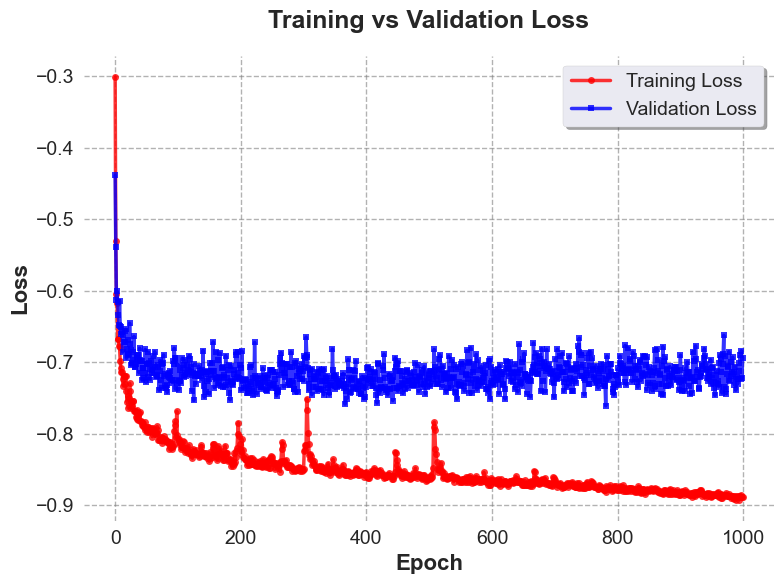

In [30]:
# Create figure with custom styling
fig, ax = plt.subplots(figsize=(8, 6))

# Combined plot with both training and validation loss
ax.plot(df["epoch"], df["train_loss"], 'r-', linewidth=2.5, marker='o', 
        markersize=5, label='Training Loss', alpha=0.8)
ax.plot(df["epoch"], df["val_loss"], 'b-', linewidth=2.5, marker='s', 
        markersize=5, label='Validation Loss', alpha=0.8)

# Styling
ax.set_title("Training vs Validation Loss", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Epoch", fontsize=16, fontweight='bold')
ax.set_ylabel("Loss", fontsize=16, fontweight='bold')
ax.legend(fontsize=14, loc='upper right', frameon=True, shadow=True)
ax.tick_params(axis='both', which='major', labelsize=14)

# White background and more visible grid
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, alpha=0.6, linestyle='--', linewidth=1, color='gray')
ax.set_axisbelow(True)  # Put grid behind the plot lines

plt.tight_layout()
fn = Path("../output/figures/nnunet_brats2017_loss_fold0_plot.tiff")
plt.savefig(fn, dpi=300)
plt.show()

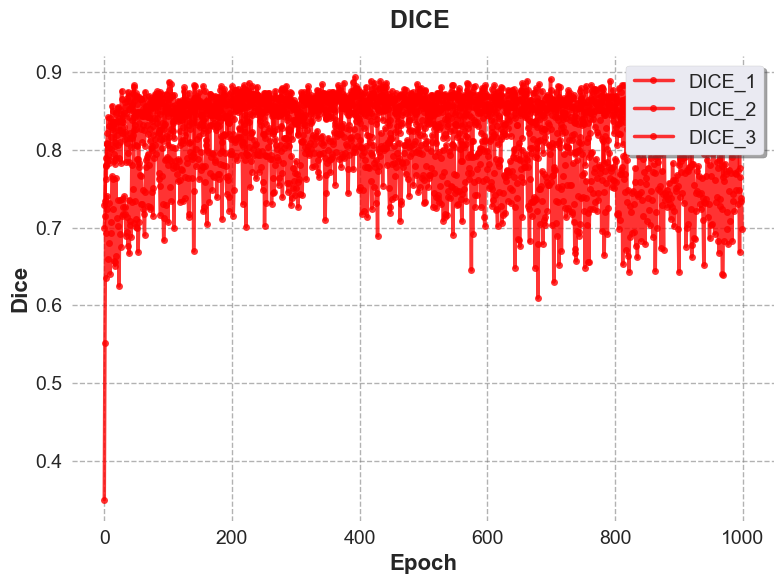

In [31]:
# Create figure with custom styling
fig, ax = plt.subplots(figsize=(8, 6))

# Combined plot with both training and validation loss
ax.plot(df["epoch"], df["DICE_1"], 'r-', linewidth=2.5, marker='o', 
        markersize=5, label='DICE_1', alpha=0.8)
ax.plot(df["epoch"], df["DICE_2"], 'r-', linewidth=2.5, marker='o', 
        markersize=5, label='DICE_2', alpha=0.8)
ax.plot(df["epoch"], df["DICE_3"], 'r-', linewidth=2.5, marker='o', 
        markersize=5, label='DICE_3', alpha=0.8)

# Styling
ax.set_title("DICE ", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Epoch", fontsize=16, fontweight='bold')
ax.set_ylabel("Dice", fontsize=16, fontweight='bold')
ax.legend(fontsize=14, loc='upper right', frameon=True, shadow=True)
ax.tick_params(axis='both', which='major', labelsize=14)

# White background and more visible grid
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, alpha=0.6, linestyle='--', linewidth=1, color='gray')
ax.set_axisbelow(True)  # Put grid behind the plot lines

plt.tight_layout()
#fn = Path("../output/figures/nnunet_brats2017_loss_fold0_plot.tiff")
#plt.savefig(fn, dpi=300)
plt.show()

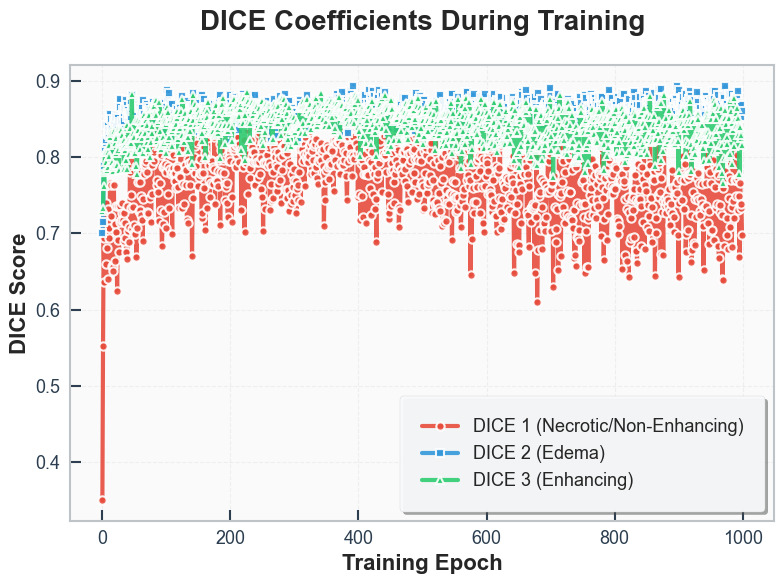

In [37]:

# Create figure with custom styling
fig, ax = plt.subplots(figsize=(8, 6))

# Define colors and markers
colors = ['#e74c3c', '#3498db', '#2ecc71']  # Red, Blue, Green
markers = ['o', 's', '^']
labels = ['DICE 1 (Necrotic/Non-Enhancing)', 'DICE 2 (Edema)', 'DICE 3 (Enhancing)']

# Plot each DICE metric
for i, (col, marker, label) in enumerate(zip(['DICE_1', 'DICE_2', 'DICE_3'], markers, labels)):
    ax.plot(df["epoch"], df[col], color=colors[i], linewidth=3, marker=marker, 
            markersize=6, label=label, alpha=0.9, 
            markeredgecolor='white', markeredgewidth=1.5)

# Enhanced styling
ax.set_title("DICE Coefficients During Training", fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel("Training Epoch", fontsize=16, fontweight='bold')
ax.set_ylabel("DICE Score", fontsize=16, fontweight='bold')

# Professional legend
legend = ax.legend(fontsize=13, loc='lower right', frameon=True, shadow=True, 
                   fancybox=True, borderpad=1.2, columnspacing=1)
legend.get_frame().set_facecolor('#f8f9fa')
legend.get_frame().set_alpha(0.95)
legend.get_frame().set_edgecolor('lightgray')

# Enhanced tick styling
ax.tick_params(axis='both', which='major', labelsize=13, direction='in', 
               length=8, width=1.5, colors='#2c3e50')
ax.tick_params(axis='both', which='minor', length=4, width=1, colors='#2c3e50')

# Grid and background
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
ax.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, color='white')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='lightgray')
ax.set_axisbelow(True)

# Set axis limits if needed
# ax.set_ylim(0, 1)  # For DICE scores typically between 0 and 1

# Add subtle border
for spine in ax.spines.values():
    spine.set_edgecolor('#bdc3c7')
    spine.set_linewidth(1.5)

plt.tight_layout()

# Save with high quality
fn = Path("../output/figures/nnunet_brats2017_dice_fold0_plot.tiff")
plt.savefig(fn, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()